# Grocery Store Sales Dataset 2025
**Dataset**: pratyushpuri/grocery-store-sales-dataset-in-2025-1900-record

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

BASE = '/Users/shardulkulkarni/Documents/Personal/Experimentation/supermarket/abhinav/grocery-store-sales-2025'
df = pd.read_csv(f'{BASE}/grocery_chain_data.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (1980, 11)
Columns: ['customer_id', 'store_name', 'transaction_date', 'aisle', 'product_name', 'quantity', 'unit_price', 'total_amount', 'discount_amount', 'final_amount', 'loyalty_points']


,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2.0,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1.0,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4.0,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3.0,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5.0,8.66,43.30,1.50,41.80,22


## 1. Data Quality & Schema

In [7]:
print('=== Data Types ===')
print(df.dtypes)
print(f'=== Null Counts ===')
print(df.isnull().sum())
print(f'=== Unique Values ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()}')


=== Data Types ===
customer_id           int64
store_name              str
transaction_date        str
aisle                   str
product_name            str
quantity            float64
unit_price          float64
total_amount        float64
discount_amount     float64
final_amount        float64
loyalty_points        int64
dtype: object
=== Null Counts ===
customer_id          0
store_name          25
transaction_date     0
aisle                0
product_name         0
quantity             0
unit_price           0
total_amount         0
discount_amount      0
final_amount         0
loyalty_points       0
dtype: int64
=== Unique Values ===
customer_id: 1798
store_name: 9
transaction_date: 689
aisle: 11
product_name: 18
quantity: 5
unit_price: 1439
total_amount: 1700
discount_amount: 864
final_amount: 1767
loyalty_points: 489


## 2. Statistical Summary

In [8]:
df.describe()

,customer_id,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
count,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000
mean,5542.958081,2.968182,15.488045,45.902576,4.469591,41.432985,255.147980
std,2575.771856,1.419028,8.400823,35.018599,4.962001,32.593328,146.009333
min,1006.000000,1.000000,0.990000,1.010000,0.000000,-3.430000,0.000000
25%,3271.500000,2.000000,8.240000,18.000000,1.240000,15.800000,128.000000
50%,5582.500000,3.000000,15.190000,37.130000,3.045000,32.820000,265.500000
75%,7791.750000,4.000000,22.862500,67.930000,5.402500,60.800000,378.000000
max,9998.000000,5.000000,29.980000,149.900000,29.940000,147.910000,500.000000


## 3. Categorical Distributions

/var/folders/pn/j2c_gyc111x0_3ngwqgc_yyw0000gn/T/ipykernel_34466/4157924479.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


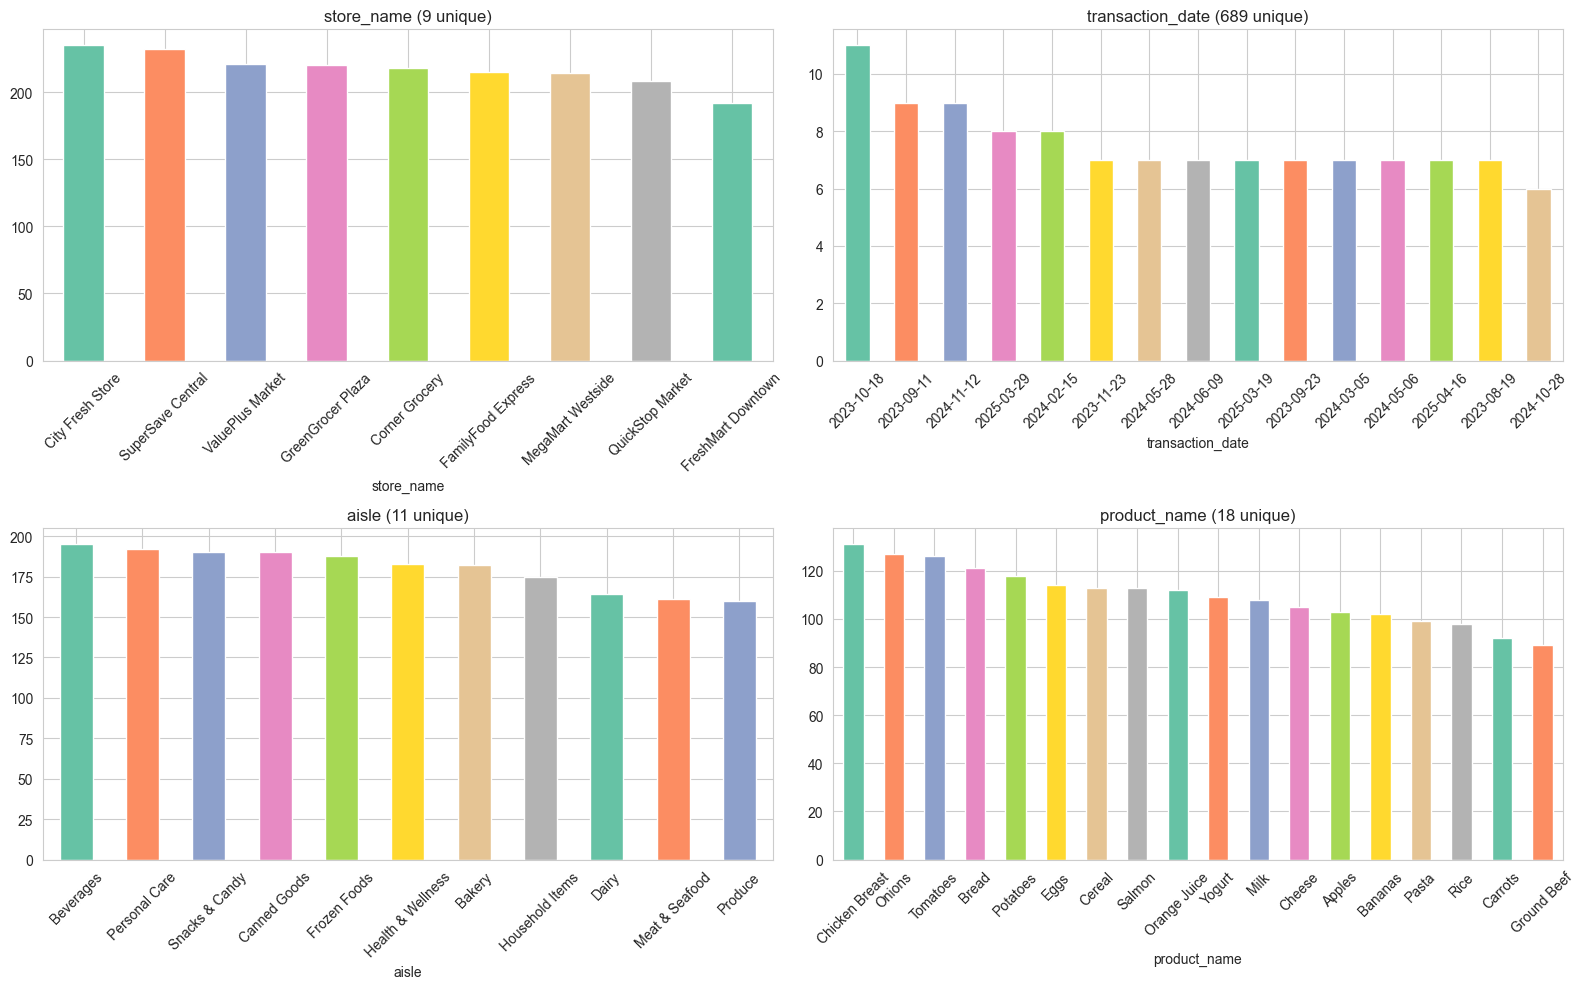

In [9]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
n = len(cat_cols)
if n > 0:
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(16, 5 * rows))
    axes = axes.flatten() if n > 2 else [axes] if n == 1 else axes.flatten()
    for i, col in enumerate(cat_cols):
        vc = df[col].value_counts()
        if len(vc) > 20:
            vc = vc.head(15)
        vc.plot(kind='bar', ax=axes[i], color=sns.color_palette('Set2', len(vc)))
        axes[i].set_title(f'{col} ({df[col].nunique()} unique)')
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


## 4. Temporal Analysis

transaction_date: 2023-08-07 00:00:00 to 2025-08-05 00:00:00 (729 days)


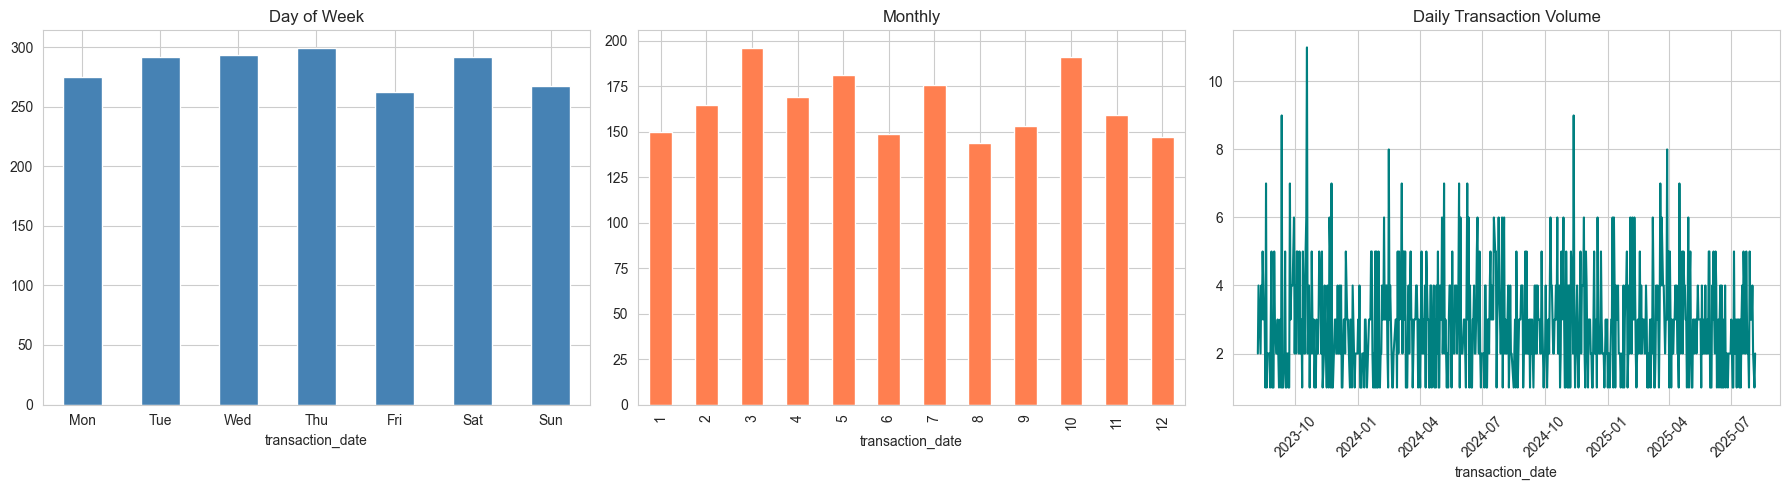

In [10]:
date_cols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f'{col}: {df[col].min()} to {df[col].max()} ({(df[col].max()-df[col].min()).days} days)')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    df[col].dt.dayofweek.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Day of Week')
    axes[0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
    
    df[col].dt.month.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Monthly')
    
    df.groupby(df[col].dt.date).size().plot(ax=axes[2], color='teal')
    axes[2].set_title('Daily Transaction Volume')
    axes[2].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


## 5. Financial Analysis

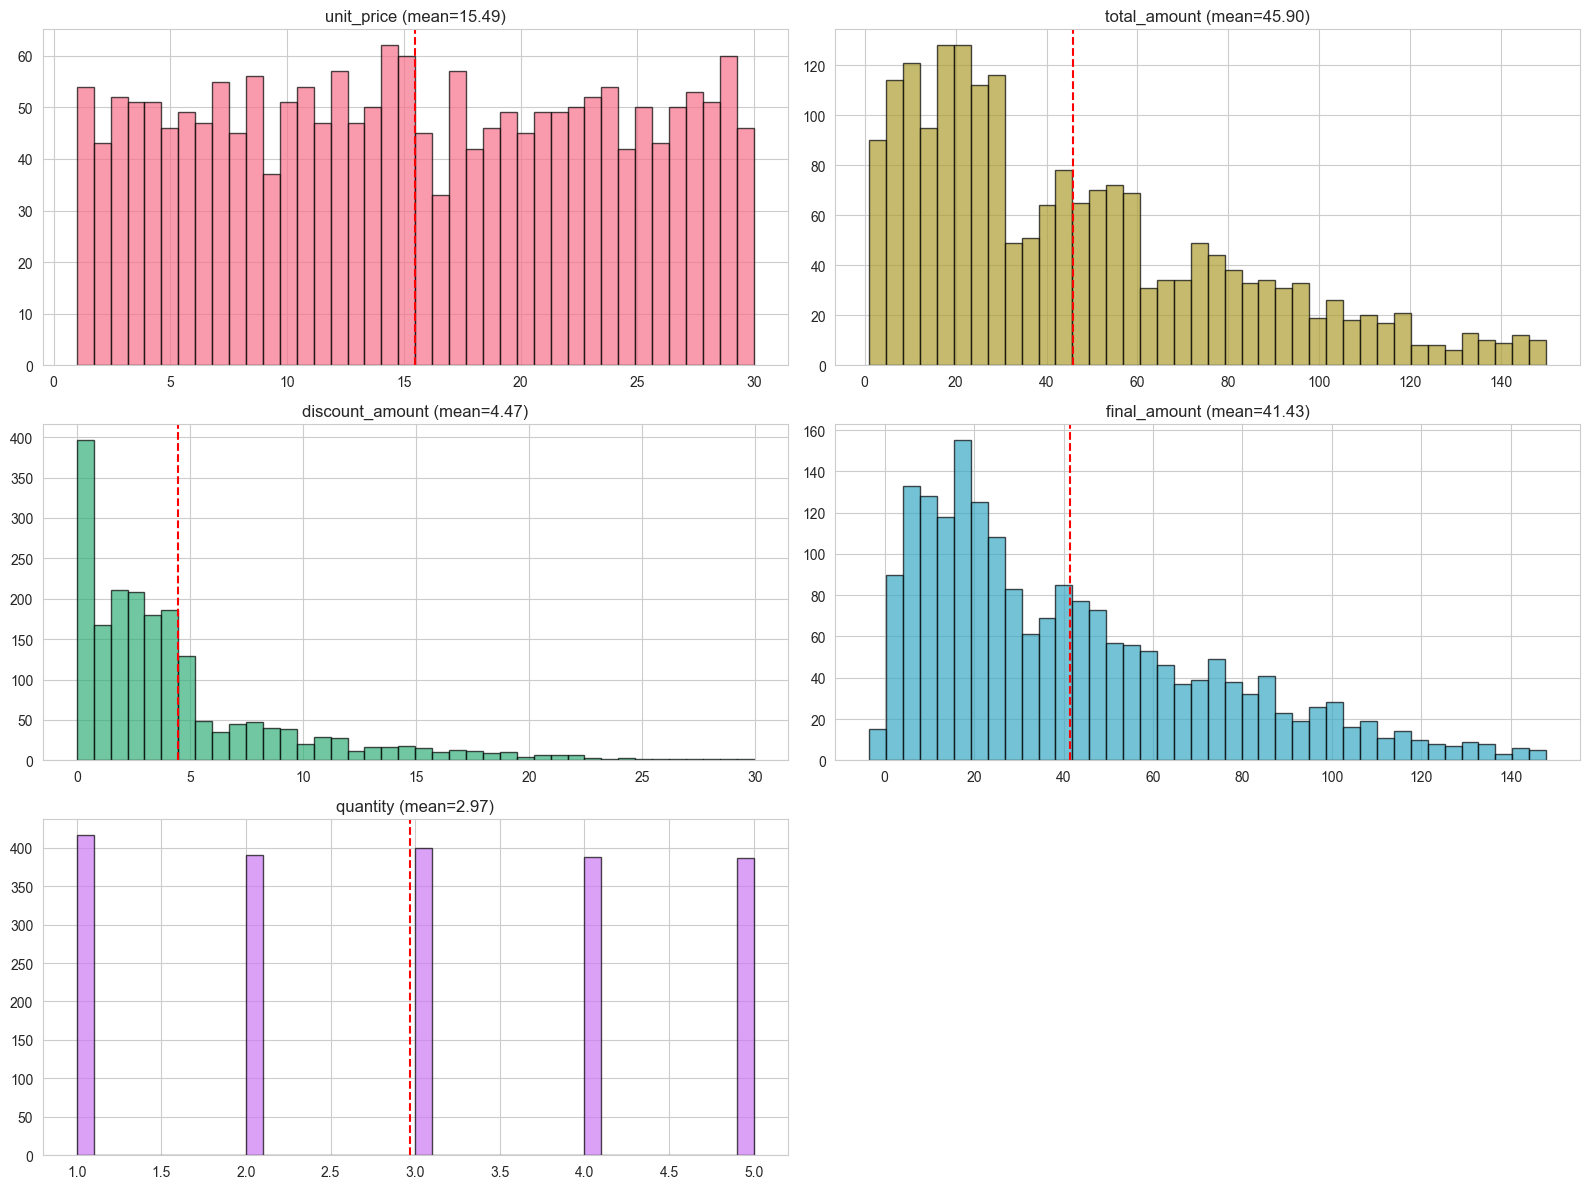

unit_price — Mean: 15.49, Median: 15.19, Total: 30,666.33
total_amount — Mean: 45.90, Median: 37.13, Total: 90,887.10
discount_amount — Mean: 4.47, Median: 3.04, Total: 8,849.79
final_amount — Mean: 41.43, Median: 32.82, Total: 82,037.31
quantity — Mean: 2.97, Median: 3.00, Total: 5,877.00


In [11]:
price_cols = [c for c in df.columns if any(k in c.lower() for k in ['price','cost','revenue','profit','margin','total','amount','sales'])]
qty_cols = [c for c in df.columns if any(k in c.lower() for k in ['quantity','qty','units'])]
fin_cols = [c for c in price_cols + qty_cols if df[c].dtype in ['float64','int64']]

if fin_cols:
    n = len(fin_cols)
    fig, axes = plt.subplots((n+1)//2, 2, figsize=(16, 4*((n+1)//2)))
    axes = axes.flatten()
    for i, col in enumerate(fin_cols):
        axes[i].hist(df[col].dropna(), bins=40, edgecolor='black', alpha=0.7, color=sns.color_palette('husl', n)[i])
        axes[i].set_title(f'{col} (mean={df[col].mean():.2f})')
        axes[i].axvline(df[col].mean(), color='red', linestyle='--')
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

for col in fin_cols:
    print(f'{col} — Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}, Total: {df[col].sum():,.2f}')


## 6. Product Performance

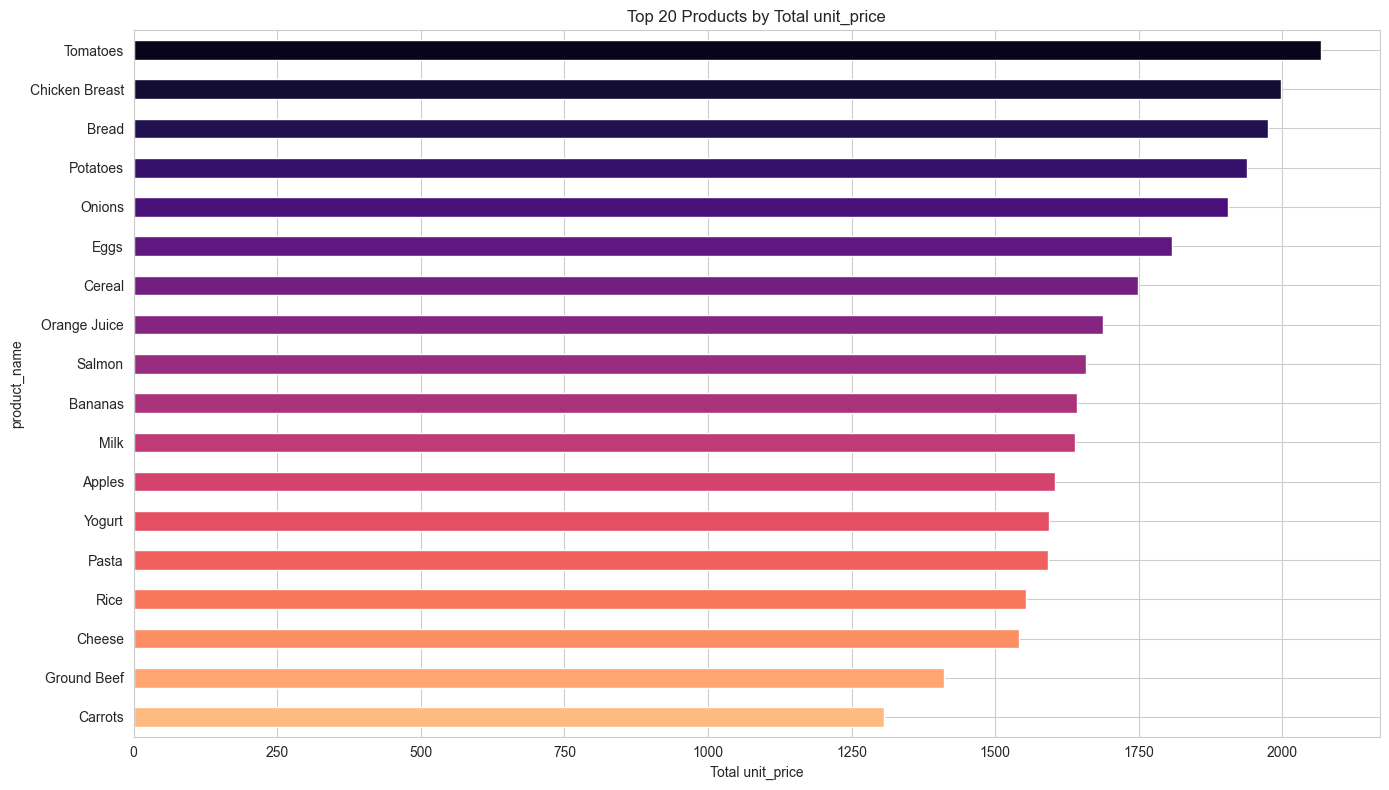

In [12]:
prod_cols = [c for c in df.columns if any(k in c.lower() for k in ['product','item','sku'])]
if prod_cols and price_cols:
    pc = prod_cols[0]
    prc = [c for c in price_cols if df[c].dtype in ['float64','int64']][0] if price_cols else None
    
    if prc:
        prod_perf = df.groupby(pc).agg(
            total_revenue=(prc, 'sum'),
            avg_revenue=(prc, 'mean'),
            count=(prc, 'count')
        ).sort_values('total_revenue', ascending=False)
        
        fig, ax = plt.subplots(figsize=(14, 8))
        prod_perf.head(20)['total_revenue'].plot(kind='barh', ax=ax, color=sns.color_palette('magma', 20))
        ax.set_title(f'Top 20 Products by Total {prc}')
        ax.set_xlabel(f'Total {prc}')
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()


## 7. Store / Location Analysis

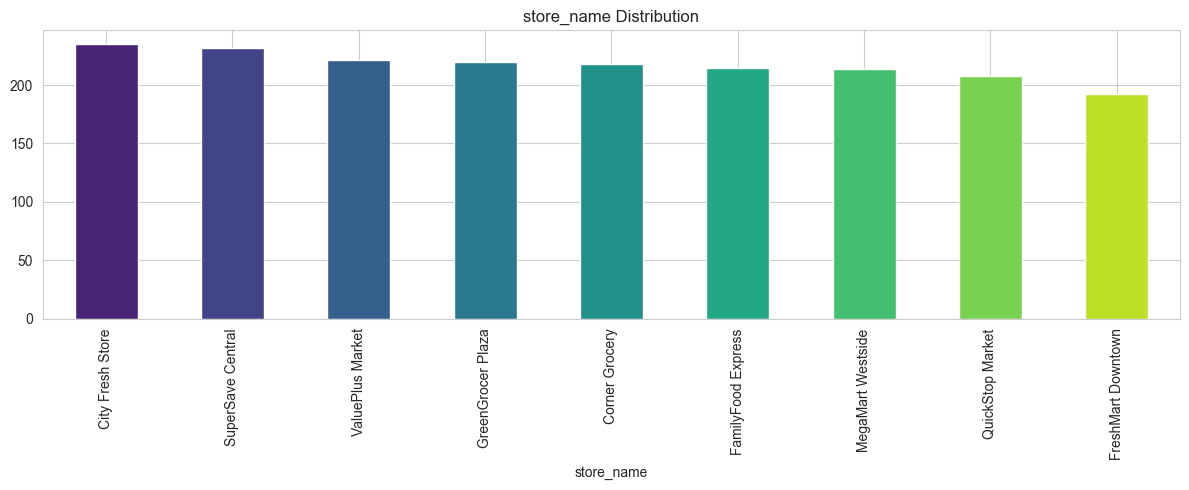

In [13]:
store_cols = [c for c in df.columns if any(k in c.lower() for k in ['store','location','branch','city','region'])]
if store_cols:
    for col in store_cols:
        if df[col].nunique() <= 30:
            fig, ax = plt.subplots(figsize=(12, 5))
            vc = df[col].value_counts()
            vc.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(vc)))
            ax.set_title(f'{col} Distribution')
            plt.tight_layout()
            plt.show()


## 8. Category Analysis

In [14]:
cat_prod_cols = [c for c in df.columns if 'category' in c.lower() or 'department' in c.lower()]
if cat_prod_cols and price_cols:
    prc = [c for c in price_cols if df[c].dtype in ['float64','int64']][0]
    for col in cat_prod_cols:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        df[col].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
        axes[0].set_title(f'{col} — Transaction Count')
        
        df.groupby(col)[prc].sum().sort_values().plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis'))
        axes[1].set_title(f'{col} — Total {prc}')
        plt.tight_layout()
        plt.show()


## 9. Correlation Matrix

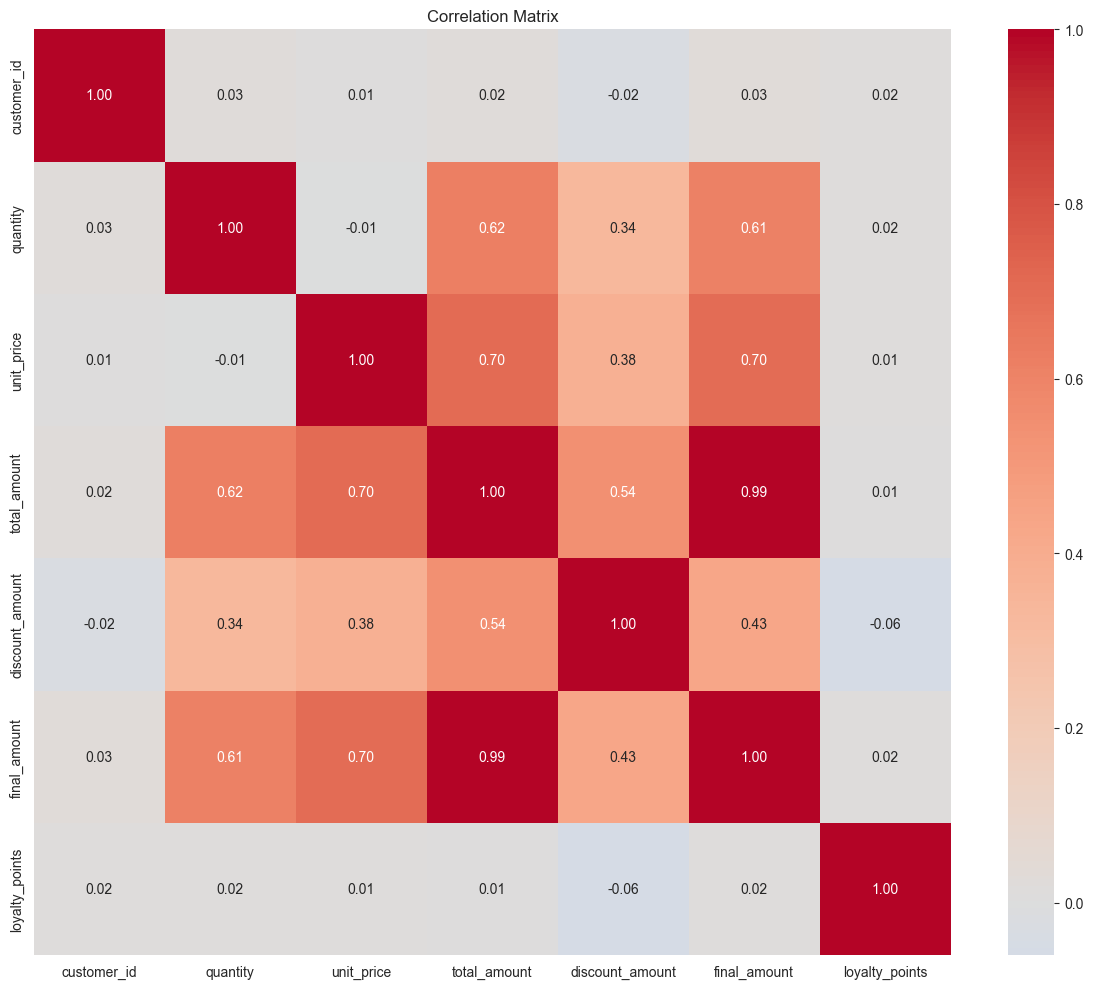

In [15]:
num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] > 2:
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0)
    ax.set_title('Correlation Matrix')
    plt.tight_layout()
    plt.show()


## 10. Relevance to Shelf Optimization / Planogram AI

**Strengths:**
- Price, cost, quantity data for margin-based SKU scoring
- Multi-store data for localized planograms
- Category data for shelf allocation
- Date data for seasonality detection

**Limitations:**
- Small dataset (1,900 records) — limited for ML training
- No physical shelf/aisle layout data
- No basket-level co-purchase data


## 11. Data Cleaning for Discount/Promotion Analysis

### Issues to Address:
- Convert `quantity` column to numeric (currently may be string)
- Identify and flag negative `final_amount` rows (potential returns/refunds)

In [16]:
# Data Cleaning
# Convert quantity to numeric (handle if it's string)
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
print(f"Quantity dtype after conversion: {df['quantity'].dtype}")

# Identify negative final_amount rows (potential returns/refunds)
df['is_negative_transaction'] = df['final_amount'] < 0
negative_transactions = df[df['is_negative_transaction']]

print(f"\n=== Negative Final Amount Analysis ===")
print(f"Total negative transactions: {len(negative_transactions)} ({len(negative_transactions)/len(df)*100:.2f}%)")
print(f"\nNegative transaction details:")
print(negative_transactions[['customer_id', 'store_name', 'product_name', 'total_amount', 'discount_amount', 'final_amount']].to_string())

# Analyze pattern: these appear to be transactions where discount_amount > total_amount
print(f"\n=== Pattern Analysis ===")
print(f"In negative transactions, discount > total_amount: {(negative_transactions['discount_amount'] > negative_transactions['total_amount']).all()}")
print(f"These are likely promotional over-discounting or data entry errors, not returns.")

Quantity dtype after conversion: float64

=== Negative Final Amount Analysis ===
Total negative transactions: 13 (0.66%)

Negative transaction details:
      customer_id          store_name product_name  total_amount  discount_amount  final_amount
1            5506    ValuePlus Market       Cheese          1.85             3.41         -1.56
28           5803   GreenGrocer Plaza       Onions          2.46             4.71         -2.25
60           7543    QuickStop Market       Yogurt          3.40             4.40         -1.00
665          5332      Corner Grocery       Cereal          3.78             4.34         -0.56
773          7022  FreshMart Downtown       Onions          1.01             4.44         -3.43
831          8538  FreshMart Downtown      Carrots          3.04             3.32         -0.28
856          8205  FreshMart Downtown       Yogurt          1.63             3.58         -1.95
1080         6912    ValuePlus Market       Yogurt          3.97             4.1

## 12. Discount Impact Analysis

Calculate discount rates and analyze their impact on basket values and categories.

In [17]:
# Calculate discount rate (discount_amount / total_amount)
df['discount_rate'] = df['discount_amount'] / df['total_amount']
df['discount_rate'] = df['discount_rate'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Categorize discount levels
df['discount_category'] = pd.cut(df['discount_rate'], 
                                  bins=[-0.01, 0, 0.05, 0.10, 0.20, 1.0, np.inf],
                                  labels=['No Discount', '0-5%', '5-10%', '10-20%', '20-100%', '>100% (Anomaly)'])

print("=== Discount Rate Statistics ===")
print(f"Mean discount rate: {df['discount_rate'].mean()*100:.2f}%")
print(f"Median discount rate: {df['discount_rate'].median()*100:.2f}%")
print(f"Max discount rate: {df['discount_rate'].max()*100:.2f}%")
print(f"\n=== Discount Category Distribution ===")
print(df['discount_category'].value_counts().sort_index())

=== Discount Rate Statistics ===
Mean discount rate: 12.84%
Median discount rate: 10.01%
Max discount rate: 439.60%

=== Discount Category Distribution ===
discount_category
No Discount        340
0-5%               222
5-10%              356
10-20%             810
20-100%            239
>100% (Anomaly)     13
Name: count, dtype: int64


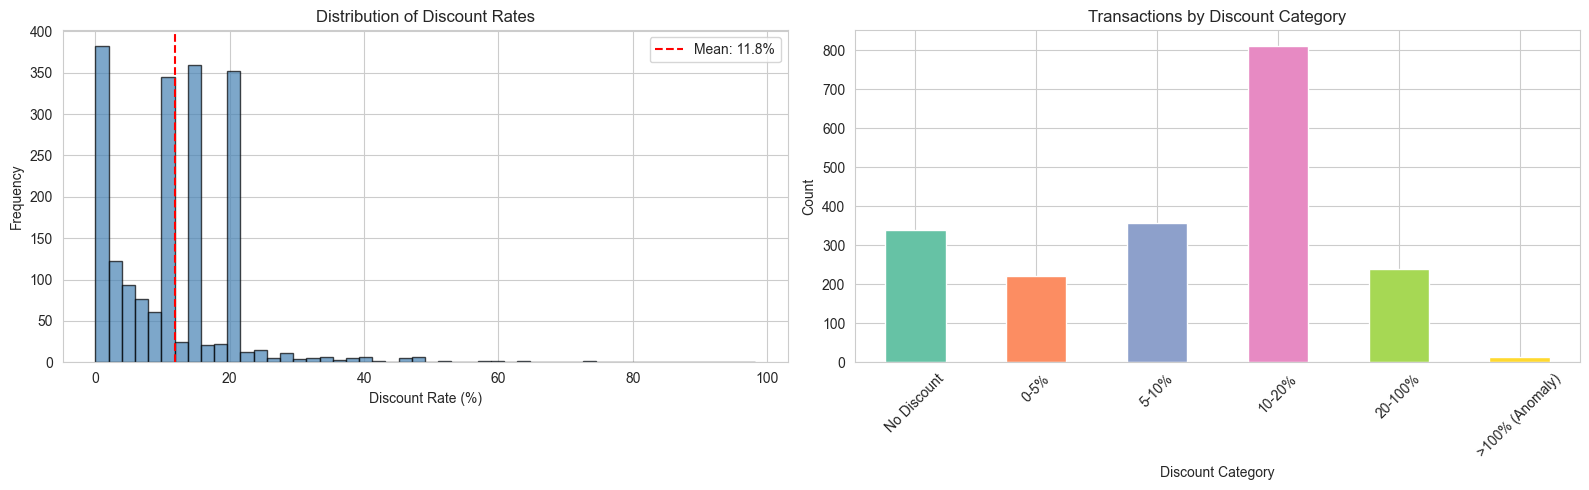

In [18]:
# Distribution of discount rates
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of discount rates (excluding extreme values for better visualization)
valid_rates = df[df['discount_rate'] <= 1]['discount_rate']
axes[0].hist(valid_rates * 100, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Discount Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Discount Rates')
axes[0].axvline(valid_rates.mean() * 100, color='red', linestyle='--', label=f'Mean: {valid_rates.mean()*100:.1f}%')
axes[0].legend()

# Discount category bar chart
df['discount_category'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Transactions by Discount Category')
axes[1].set_xlabel('Discount Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

=== Basket Value Comparison: High Discount vs No Discount ===
                   No Discount  High Discount (15%+)
Avg Total Amount         44.80                 37.68
Avg Quantity              2.98                  2.78
Transaction Count       340.00                708.00


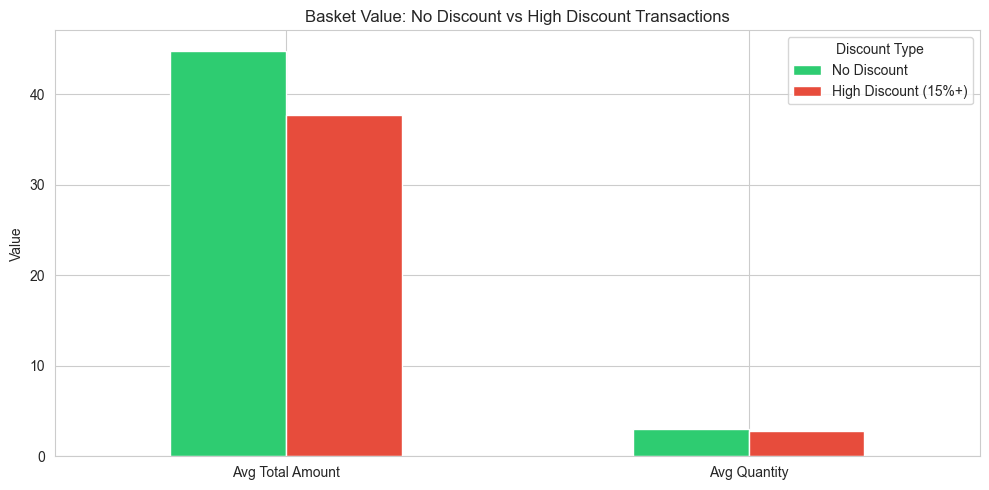

In [19]:
# Impact on basket value: High discount vs No discount transactions
no_discount = df[df['discount_amount'] == 0]
high_discount = df[df['discount_rate'] >= 0.15]  # 15%+ discount

print("=== Basket Value Comparison: High Discount vs No Discount ===")
comparison = pd.DataFrame({
    'No Discount': [no_discount['total_amount'].mean(), no_discount['quantity'].mean(), len(no_discount)],
    'High Discount (15%+)': [high_discount['total_amount'].mean(), high_discount['quantity'].mean(), len(high_discount)]
}, index=['Avg Total Amount', 'Avg Quantity', 'Transaction Count'])
print(comparison.round(2))

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
comparison.iloc[:2].plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Basket Value: No Discount vs High Discount Transactions')
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Discount Type')
plt.tight_layout()
plt.show()

=== Most Discounted Aisles ===
                   discount_rate  discount_amount  total_amount  \
aisle                                                             
Beverages                  0.143           928.72       8748.97   
Canned Goods               0.142           871.01       8917.59   
Bakery                     0.140           752.12       8313.37   
Frozen Foods               0.138           795.27       7973.12   
Snacks & Candy             0.134           947.39       9014.34   
Dairy                      0.129           801.71       8184.91   
Health & Wellness          0.120           733.81       8639.25   
Household Items            0.119           747.99       7648.27   
Personal Care              0.119           871.78       9160.90   
Produce                    0.112           679.93       6775.11   
Meat & Seafood             0.110           720.06       7511.27   

                   total_discount_rate  
aisle                                   
Beverages      

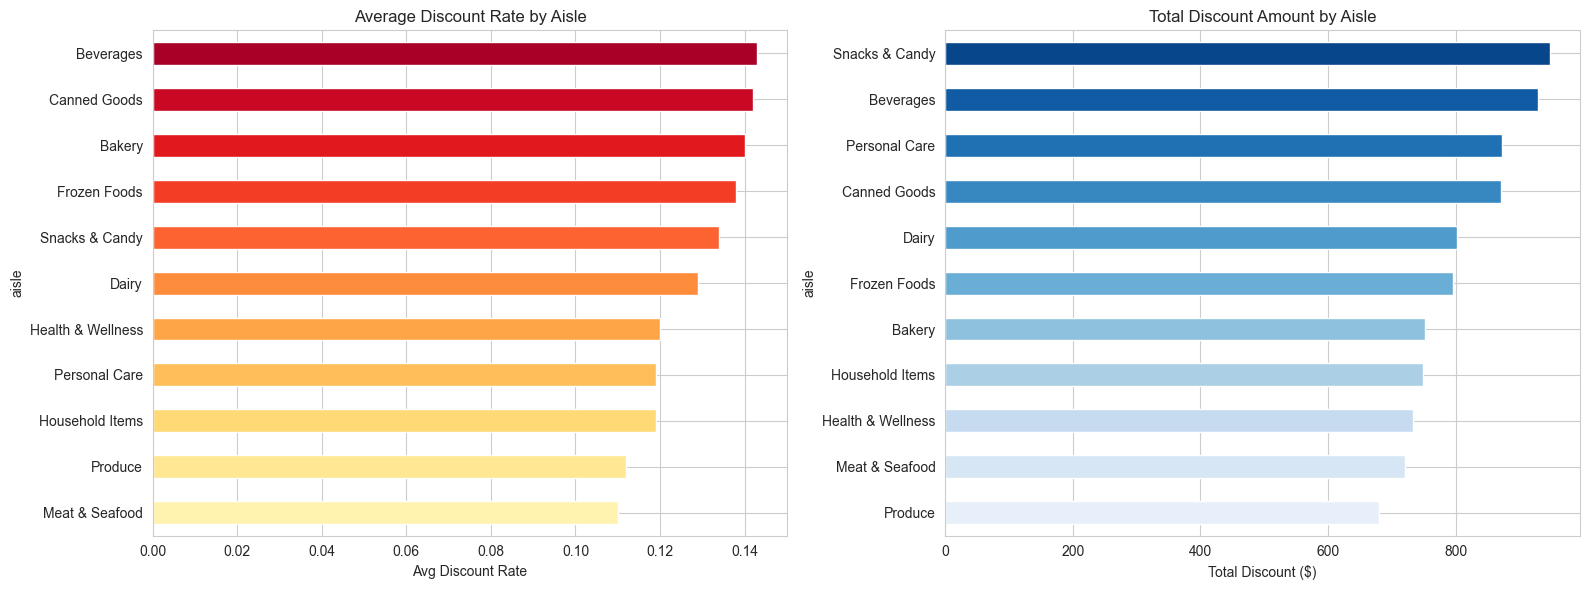

In [20]:
# Which aisles/products are most discounted?
print("=== Most Discounted Aisles ===")
aisle_discount = df.groupby('aisle').agg({
    'discount_rate': 'mean',
    'discount_amount': 'sum',
    'total_amount': 'sum'
}).round(3)
aisle_discount['total_discount_rate'] = (aisle_discount['discount_amount'] / aisle_discount['total_amount'] * 100).round(2)
aisle_discount = aisle_discount.sort_values('discount_rate', ascending=False)
print(aisle_discount)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average discount rate by aisle
aisle_discount['discount_rate'].sort_values().plot(kind='barh', ax=axes[0], color=sns.color_palette('YlOrRd', len(aisle_discount)))
axes[0].set_title('Average Discount Rate by Aisle')
axes[0].set_xlabel('Avg Discount Rate')

# Total discount amount by aisle
aisle_discount['discount_amount'].sort_values().plot(kind='barh', ax=axes[1], color=sns.color_palette('Blues', len(aisle_discount)))
axes[1].set_title('Total Discount Amount by Aisle')
axes[1].set_xlabel('Total Discount ($)')

plt.tight_layout()
plt.show()

=== Most Discounted Products ===
              discount_rate  discount_amount  total_amount  transaction_count  \
product_name                                                                    
Onions                0.168           559.00       5170.75                127   
Cheese                0.158           436.28       4616.18                105   
Yogurt                0.153           472.29       4833.34                109   
Bread                 0.146           575.58       5924.94                121   
Eggs                  0.144           600.48       5426.07                114   
Milk                  0.139           508.48       4339.32                108   
Carrots               0.129           381.99       3746.28                 92   
Orange Juice          0.120           546.57       5147.71                112   
Tomatoes              0.120           586.12       5967.83                126   
Bananas               0.119           495.07       5205.83                10

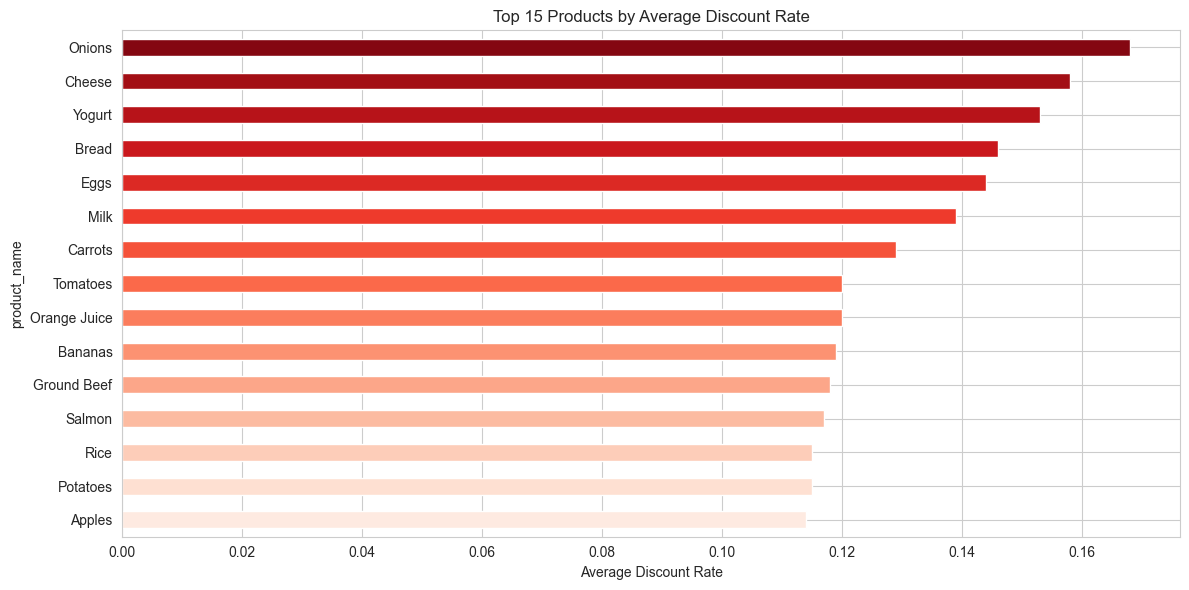

In [21]:
# Most discounted products
print("=== Most Discounted Products ===")
product_discount = df.groupby('product_name').agg({
    'discount_rate': 'mean',
    'discount_amount': 'sum',
    'total_amount': 'sum',
    'final_amount': 'count'
}).rename(columns={'final_amount': 'transaction_count'}).round(3)
product_discount['total_discount_rate'] = (product_discount['discount_amount'] / product_discount['total_amount'] * 100).round(2)
product_discount = product_discount.sort_values('discount_rate', ascending=False)
print(product_discount.head(10))

fig, ax = plt.subplots(figsize=(12, 6))
product_discount['discount_rate'].head(15).sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('Reds', 15))
ax.set_title('Top 15 Products by Average Discount Rate')
ax.set_xlabel('Average Discount Rate')
plt.tight_layout()
plt.show()

## 13. Store Performance KPIs

Comprehensive store-level analysis including AOV, basket size, discount rate, and loyalty points.

In [22]:
# Store Performance KPIs
store_kpis = df[df['store_name'].notna()].groupby('store_name').agg({
    'final_amount': ['mean', 'sum', 'count'],  # AOV and revenue
    'quantity': 'mean',                         # Basket size
    'discount_rate': 'mean',                    # Discount rate
    'loyalty_points': 'mean',                   # Loyalty points
    'discount_amount': 'sum'                    # Total discounts given
}).round(2)

store_kpis.columns = ['AOV', 'Total_Revenue', 'Transaction_Count', 'Avg_Basket_Size', 
                      'Avg_Discount_Rate', 'Avg_Loyalty_Points', 'Total_Discounts']

# Calculate discount as % of revenue
store_kpis['Discount_Pct_of_Revenue'] = (store_kpis['Total_Discounts'] / 
                                          (store_kpis['Total_Revenue'] + store_kpis['Total_Discounts']) * 100).round(2)

print("=== Store Performance KPIs ===")
print(store_kpis.to_string())

=== Store Performance KPIs ===
                      AOV  Total_Revenue  Transaction_Count  Avg_Basket_Size  Avg_Discount_Rate  Avg_Loyalty_Points  Total_Discounts  Discount_Pct_of_Revenue
store_name                                                                                                                                                   
City Fresh Store    41.65        9788.70                235             2.93               0.12              252.96          1099.42                    10.10
Corner Grocery      42.59        9285.50                218             3.03               0.13              248.90           968.32                     9.44
FamilyFood Express  35.90        7719.49                215             2.84               0.13              264.84           869.00                    10.12
FreshMart Downtown  42.74        8206.87                192             2.84               0.15              262.67           858.33                     9.47
GreenGrocer Plaza   4

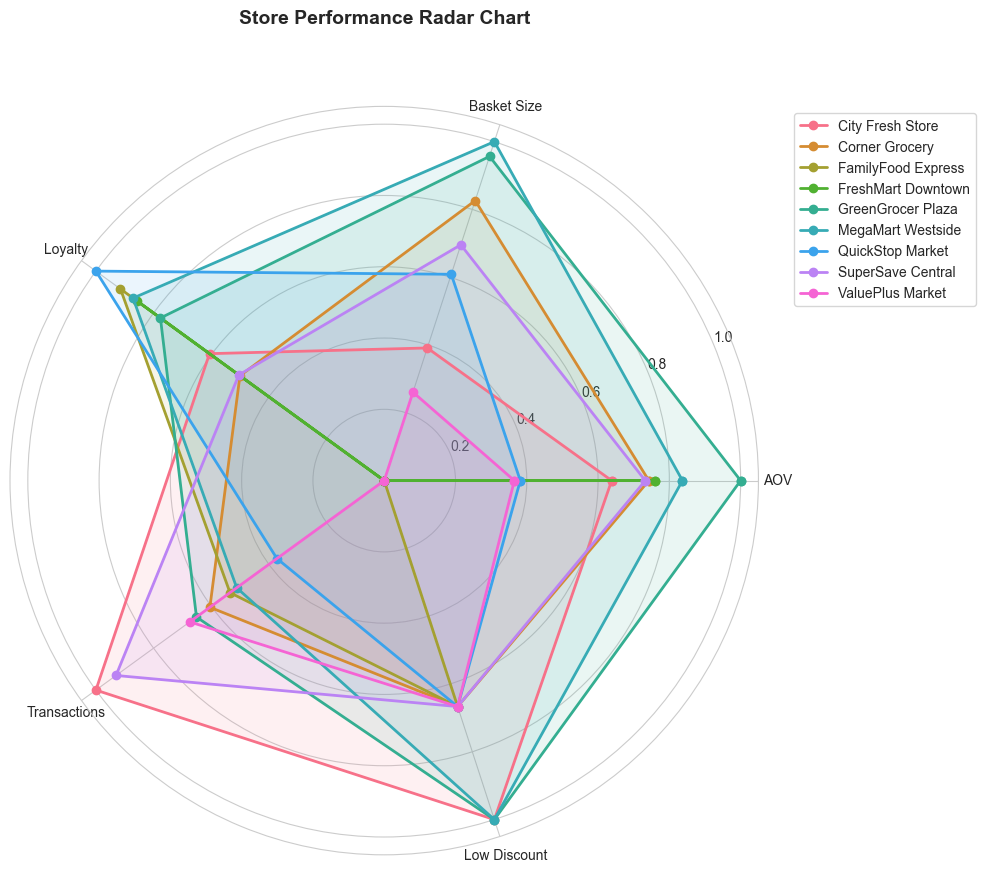

In [23]:
# Radar Chart for Store Comparison
from math import pi

# Normalize KPIs to 0-1 scale for radar chart
radar_metrics = ['AOV', 'Avg_Basket_Size', 'Avg_Loyalty_Points', 'Transaction_Count']
radar_data = store_kpis[radar_metrics].copy()

# Normalize
for col in radar_metrics:
    radar_data[col] = (radar_data[col] - radar_data[col].min()) / (radar_data[col].max() - radar_data[col].min())

# Add inverse discount rate (lower is better)
radar_data['Low_Discount_Rate'] = 1 - (store_kpis['Avg_Discount_Rate'] - store_kpis['Avg_Discount_Rate'].min()) / \
                                   (store_kpis['Avg_Discount_Rate'].max() - store_kpis['Avg_Discount_Rate'].min())

# Radar chart
categories = ['AOV', 'Basket Size', 'Loyalty', 'Transactions', 'Low Discount']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors = sns.color_palette('husl', len(radar_data))
for idx, (store, row) in enumerate(radar_data.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=store, color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title('Store Performance Radar Chart', size=14, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

=== Best & Worst Performing Stores ===

Top 3 Performing Stores:
                     AOV  Avg_Discount_Rate  Avg_Loyalty_Points  \
store_name                                                        
GreenGrocer Plaza  44.91               0.12              259.51   
MegaMart Westside  43.44               0.12              263.16   
City Fresh Store   41.65               0.12              252.96   

                   Performance_Score  
store_name                            
GreenGrocer Plaza              0.750  
MegaMart Westside              0.741  
City Fresh Store               0.714  

Bottom 3 Performing Stores:
                      AOV  Avg_Discount_Rate  Avg_Loyalty_Points  \
store_name                                                         
FreshMart Downtown  42.74               0.15              262.67   
FamilyFood Express  35.90               0.13              264.84   
ValuePlus Market    39.19               0.13              229.65   

                    Performance_Sc

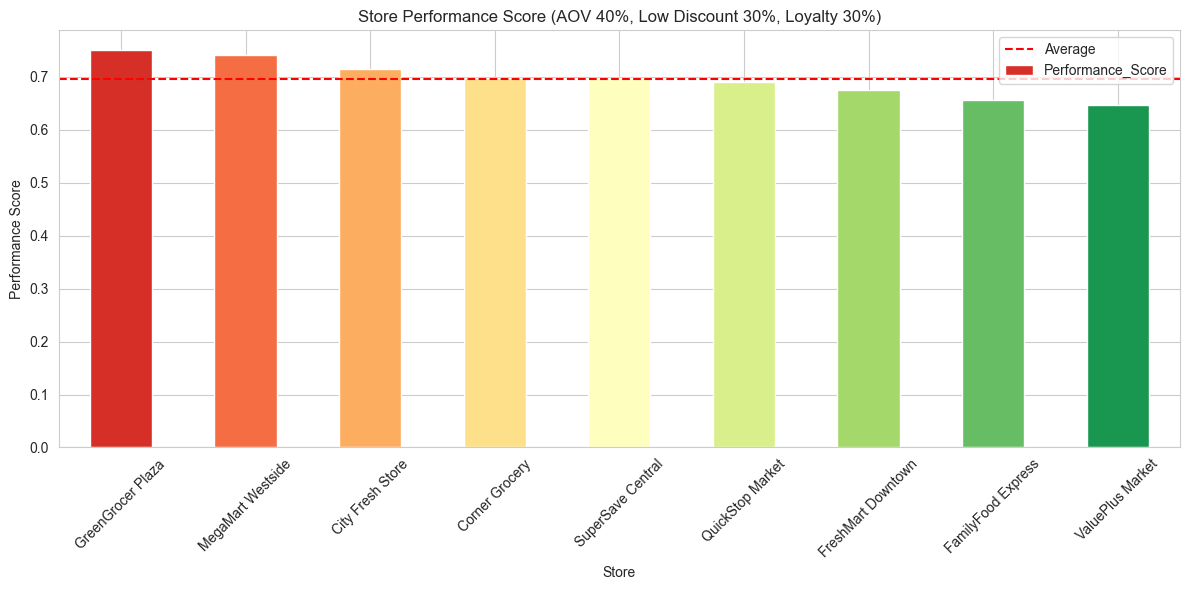

In [24]:
# Best and Worst Performing Stores
print("=== Best & Worst Performing Stores ===")

# Scoring: Higher AOV, Lower Discount Rate, Higher Loyalty = Better
store_kpis['Performance_Score'] = (
    (store_kpis['AOV'] / store_kpis['AOV'].max()) * 0.4 +
    (1 - store_kpis['Avg_Discount_Rate'] / store_kpis['Avg_Discount_Rate'].max()) * 0.3 +
    (store_kpis['Avg_Loyalty_Points'] / store_kpis['Avg_Loyalty_Points'].max()) * 0.3
).round(3)

store_kpis_sorted = store_kpis.sort_values('Performance_Score', ascending=False)

print("\nTop 3 Performing Stores:")
print(store_kpis_sorted[['AOV', 'Avg_Discount_Rate', 'Avg_Loyalty_Points', 'Performance_Score']].head(3))

print("\nBottom 3 Performing Stores:")
print(store_kpis_sorted[['AOV', 'Avg_Discount_Rate', 'Avg_Loyalty_Points', 'Performance_Score']].tail(3))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
store_kpis_sorted['Performance_Score'].plot(kind='bar', ax=ax, color=sns.color_palette('RdYlGn', len(store_kpis_sorted)))
ax.set_title('Store Performance Score (AOV 40%, Low Discount 30%, Loyalty 30%)')
ax.set_xlabel('Store')
ax.set_ylabel('Performance Score')
ax.tick_params(axis='x', rotation=45)
ax.axhline(store_kpis_sorted['Performance_Score'].mean(), color='red', linestyle='--', label='Average')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Loyalty Points Analysis

Analyze correlation between loyalty points and spending, and examine loyalty behavior patterns.

=== Loyalty Points Correlation Analysis ===
loyalty_points     1.000
final_amount       0.016
total_amount       0.006
quantity           0.018
discount_amount   -0.060
Name: loyalty_points, dtype: float64


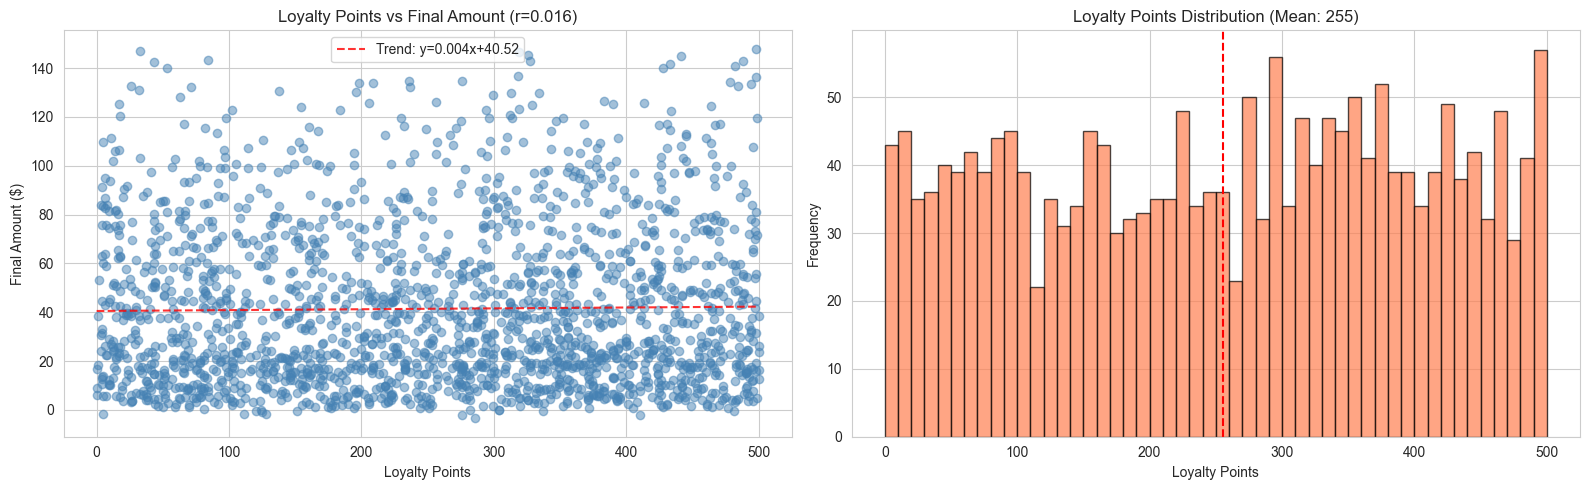

In [25]:
# Correlation between loyalty points and spending
print("=== Loyalty Points Correlation Analysis ===")
loyalty_corr = df[['loyalty_points', 'final_amount', 'total_amount', 'quantity', 'discount_amount']].corr()
print(loyalty_corr['loyalty_points'].round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter plot: Loyalty points vs Final Amount
axes[0].scatter(df['loyalty_points'], df['final_amount'], alpha=0.5, c='steelblue')
axes[0].set_xlabel('Loyalty Points')
axes[0].set_ylabel('Final Amount ($)')
axes[0].set_title(f'Loyalty Points vs Final Amount (r={loyalty_corr.loc["loyalty_points", "final_amount"]:.3f})')

# Add trend line
z = np.polyfit(df['loyalty_points'], df['final_amount'], 1)
p = np.poly1d(z)
axes[0].plot(df['loyalty_points'].sort_values(), p(df['loyalty_points'].sort_values()), 
             "r--", alpha=0.8, label=f'Trend: y={z[0]:.3f}x+{z[1]:.2f}')
axes[0].legend()

# Loyalty points distribution
axes[1].hist(df['loyalty_points'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Loyalty Points')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Loyalty Points Distribution (Mean: {df["loyalty_points"].mean():.0f})')
axes[1].axvline(df['loyalty_points'].mean(), color='red', linestyle='--')

plt.tight_layout()
plt.show()

=== Loyalty Points by Aisle ===
                     mean    sum  count
aisle                                  
Health & Wellness  274.92  50310    183
Bakery             262.38  47754    182
Canned Goods       262.17  49813    190
Frozen Foods       258.80  48655    188
Beverages          253.69  49469    195
Dairy              252.29  41375    164
Produce            251.55  40248    160
Snacks & Candy     251.17  47722    190
Household Items    250.90  43907    175
Meat & Seafood     248.19  39958    161
Personal Care      239.49  45982    192


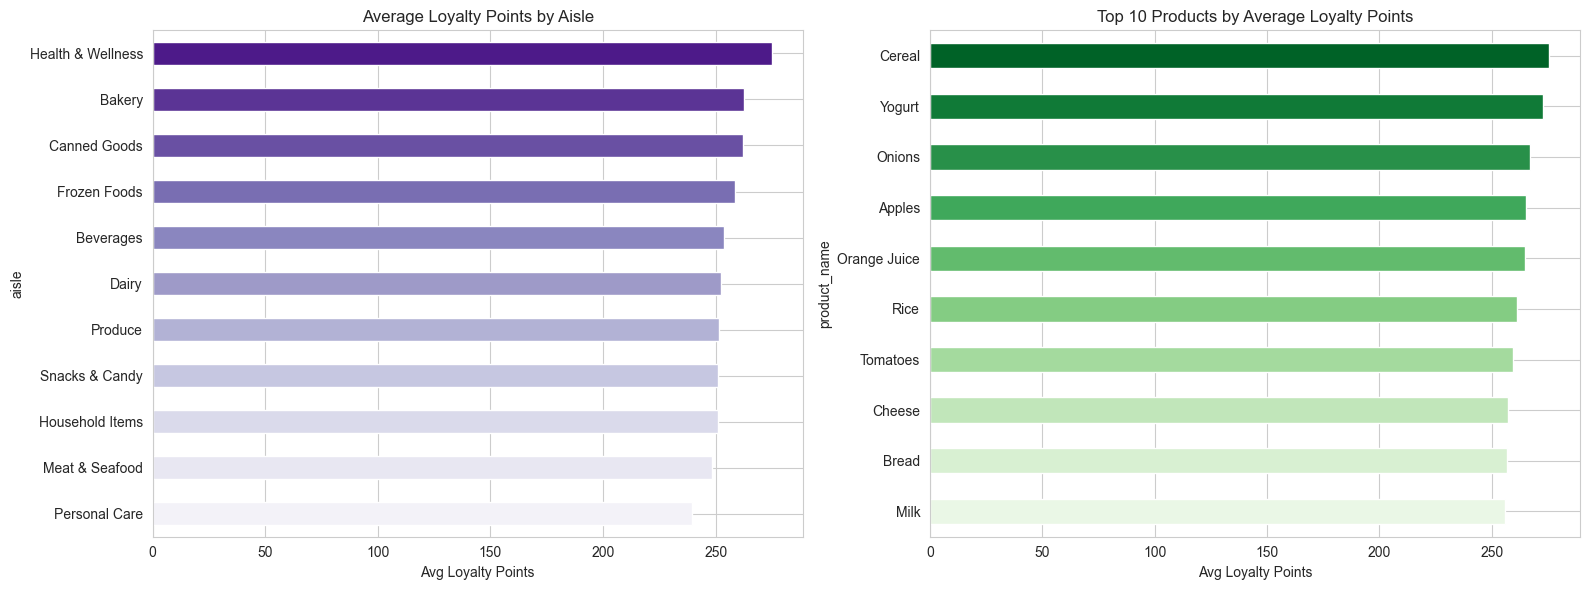

In [26]:
# Loyalty points by aisle and product
print("=== Loyalty Points by Aisle ===")
aisle_loyalty = df.groupby('aisle')['loyalty_points'].agg(['mean', 'sum', 'count']).round(2)
aisle_loyalty = aisle_loyalty.sort_values('mean', ascending=False)
print(aisle_loyalty)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

aisle_loyalty['mean'].sort_values().plot(kind='barh', ax=axes[0], color=sns.color_palette('Purples', len(aisle_loyalty)))
axes[0].set_title('Average Loyalty Points by Aisle')
axes[0].set_xlabel('Avg Loyalty Points')

# Product loyalty
product_loyalty = df.groupby('product_name')['loyalty_points'].agg(['mean', 'count']).round(2)
product_loyalty = product_loyalty.sort_values('mean', ascending=False)
product_loyalty['mean'].head(10).sort_values().plot(kind='barh', ax=axes[1], color=sns.color_palette('Greens', 10))
axes[1].set_title('Top 10 Products by Average Loyalty Points')
axes[1].set_xlabel('Avg Loyalty Points')

plt.tight_layout()
plt.show()

=== High-Loyalty vs Low-Loyalty Customer Behavior ===
              final_amount  quantity  discount_rate  transaction_count
loyalty_tier                                                          
Low                 41.277     2.947          0.133                663
Medium              41.033     2.942          0.137                657
High                41.987     3.015          0.115                660


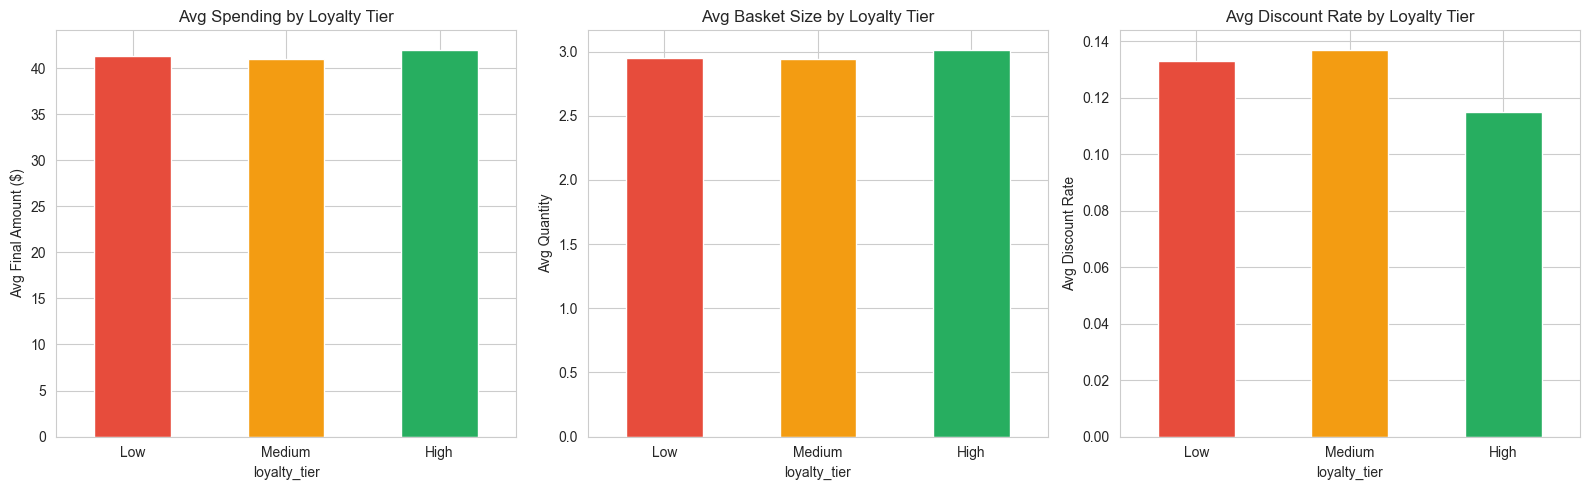

In [27]:
# High-loyalty vs Low-loyalty customer behavior
df['loyalty_tier'] = pd.qcut(df['loyalty_points'], q=3, labels=['Low', 'Medium', 'High'])

print("=== High-Loyalty vs Low-Loyalty Customer Behavior ===")
loyalty_behavior = df.groupby('loyalty_tier').agg({
    'final_amount': 'mean',
    'quantity': 'mean',
    'discount_rate': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'transaction_count'}).round(3)
print(loyalty_behavior)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

loyalty_behavior['final_amount'].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#f39c12', '#27ae60'])
axes[0].set_title('Avg Spending by Loyalty Tier')
axes[0].set_ylabel('Avg Final Amount ($)')
axes[0].tick_params(axis='x', rotation=0)

loyalty_behavior['quantity'].plot(kind='bar', ax=axes[1], color=['#e74c3c', '#f39c12', '#27ae60'])
axes[1].set_title('Avg Basket Size by Loyalty Tier')
axes[1].set_ylabel('Avg Quantity')
axes[1].tick_params(axis='x', rotation=0)

loyalty_behavior['discount_rate'].plot(kind='bar', ax=axes[2], color=['#e74c3c', '#f39c12', '#27ae60'])
axes[2].set_title('Avg Discount Rate by Loyalty Tier')
axes[2].set_ylabel('Avg Discount Rate')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 15. Anomaly Detection

Flag unusual transactions including negative amounts, extreme discounts, and analyze patterns.

In [28]:
# Anomaly Detection
# Flag types of anomalies
df['anomaly_negative_amount'] = df['final_amount'] < 0
df['anomaly_extreme_discount'] = df['discount_rate'] > 0.5  # >50% discount
df['anomaly_discount_exceeds_total'] = df['discount_amount'] > df['total_amount']
df['is_anomaly'] = df['anomaly_negative_amount'] | df['anomaly_extreme_discount'] | df['anomaly_discount_exceeds_total']

print("=== Anomaly Summary ===")
print(f"Total transactions: {len(df)}")
print(f"Negative final_amount: {df['anomaly_negative_amount'].sum()} ({df['anomaly_negative_amount'].mean()*100:.2f}%)")
print(f"Extreme discount (>50%): {df['anomaly_extreme_discount'].sum()} ({df['anomaly_extreme_discount'].mean()*100:.2f}%)")
print(f"Discount exceeds total: {df['anomaly_discount_exceeds_total'].sum()} ({df['anomaly_discount_exceeds_total'].mean()*100:.2f}%)")
print(f"Total anomalous transactions: {df['is_anomaly'].sum()} ({df['is_anomaly'].mean()*100:.2f}%)")

# Display sample anomalies
print("\n=== Sample Anomalous Transactions ===")
anomalies = df[df['is_anomaly']]
print(anomalies[['customer_id', 'store_name', 'product_name', 'total_amount', 
                 'discount_amount', 'final_amount', 'discount_rate']].head(10).to_string())

=== Anomaly Summary ===
Total transactions: 1980
Negative final_amount: 13 (0.66%)
Extreme discount (>50%): 35 (1.77%)
Discount exceeds total: 13 (0.66%)
Total anomalous transactions: 35 (1.77%)

=== Sample Anomalous Transactions ===
     customer_id          store_name product_name  total_amount  discount_amount  final_amount  discount_rate
1           5506    ValuePlus Market       Cheese          1.85             3.41         -1.56       1.843243
26          3045      Corner Grocery         Milk          2.75             1.99          0.76       0.723636
28          5803   GreenGrocer Plaza       Onions          2.46             4.71         -2.25       1.914634
60          7543    QuickStop Market       Yogurt          3.40             4.40         -1.00       1.294118
78          3591  FreshMart Downtown         Eggs          9.30             4.79          4.51       0.515054
199         6617   SuperSave Central         Eggs          7.50             4.74          2.76       0.632

=== Anomaly Patterns by Store ===
                    Anomaly_Count  Total  Rate_%
store_name                                      
City Fresh Store                5    235    2.13
Corner Grocery                  6    218    2.75
FamilyFood Express              2    215    0.93
FreshMart Downtown              5    192    2.60
GreenGrocer Plaza               4    220    1.82
MegaMart Westside               2    214    0.93
QuickStop Market                2    208    0.96
SuperSave Central               6    232    2.59
ValuePlus Market                3    221    1.36

=== Anomaly Patterns by Product ===
product_name
Yogurt      5
Cheese      4
Onions      4
Bread       4
Eggs        3
Potatoes    3
Milk        2
Tomatoes    2
Cereal      1
Carrots     1
Name: count, dtype: int64

=== Anomaly Patterns by Aisle ===
aisle
Bakery               5
Beverages            4
Household Items      4
Frozen Foods         4
Dairy                3
Health & Wellness    3
Canned Goods         3
Personal 

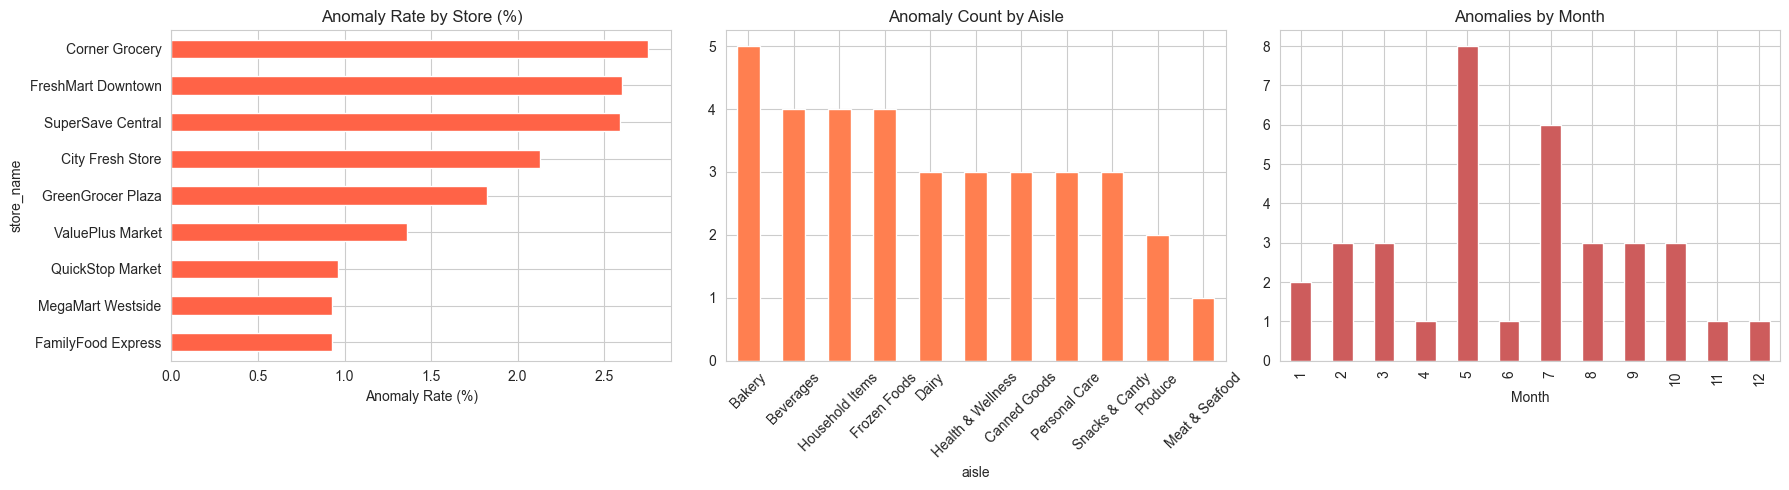

In [29]:
# Patterns in anomalies - by store, product, time
if len(anomalies) > 0:
    print("=== Anomaly Patterns by Store ===")
    store_anomalies = anomalies['store_name'].value_counts()
    store_total = df['store_name'].value_counts()
    store_anomaly_rate = (store_anomalies / store_total * 100).round(2)
    print(pd.DataFrame({'Anomaly_Count': store_anomalies, 'Total': store_total, 'Rate_%': store_anomaly_rate}))
    
    print("\n=== Anomaly Patterns by Product ===")
    product_anomalies = anomalies['product_name'].value_counts()
    print(product_anomalies.head(10))
    
    print("\n=== Anomaly Patterns by Aisle ===")
    aisle_anomalies = anomalies['aisle'].value_counts()
    print(aisle_anomalies)
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    store_anomaly_rate.dropna().sort_values().plot(kind='barh', ax=axes[0], color='tomato')
    axes[0].set_title('Anomaly Rate by Store (%)')
    axes[0].set_xlabel('Anomaly Rate (%)')
    
    aisle_anomalies.plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Anomaly Count by Aisle')
    axes[1].tick_params(axis='x', rotation=45)
    
    # Time pattern
    anomalies['transaction_date'] = pd.to_datetime(anomalies['transaction_date'])
    anomalies.groupby(anomalies['transaction_date'].dt.month).size().plot(kind='bar', ax=axes[2], color='indianred')
    axes[2].set_title('Anomalies by Month')
    axes[2].set_xlabel('Month')
    
    plt.tight_layout()
    plt.show()
else:
    print("No anomalies detected.")

## 16. Customer Behavior Segmentation

Analyze customer transaction patterns, store loyalty, and aisle preferences.

=== Customer Transaction Frequency ===
count    1798.000000
mean        1.101224
std         0.328211
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: transaction_count, dtype: float64

=== Customer Frequency Segments ===
frequency_segment
One-time        1630
Low (2)          155
Medium (3-5)      13
High (5+)          0
Name: count, dtype: int64


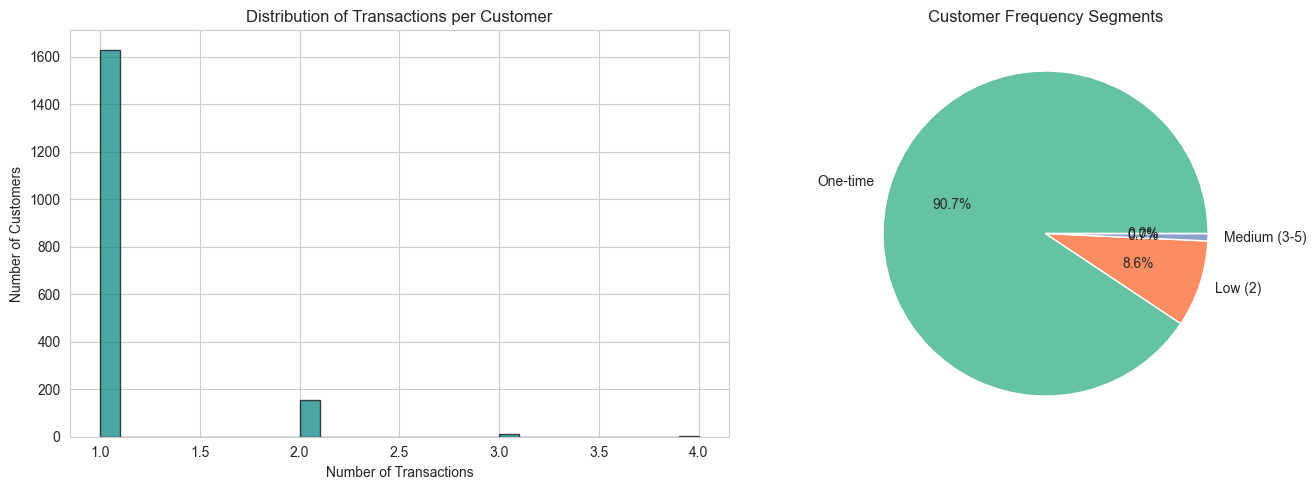

In [30]:
# Customer transaction frequency
customer_stats = df.groupby('customer_id').agg({
    'final_amount': ['count', 'sum', 'mean'],
    'store_name': 'nunique',
    'aisle': 'nunique',
    'loyalty_points': 'mean'
}).round(2)

customer_stats.columns = ['transaction_count', 'total_spend', 'avg_spend', 
                          'stores_visited', 'aisles_shopped', 'avg_loyalty_points']

print("=== Customer Transaction Frequency ===")
print(customer_stats['transaction_count'].describe())

# Categorize customers by transaction frequency
customer_stats['frequency_segment'] = pd.cut(customer_stats['transaction_count'], 
                                              bins=[0, 1, 2, 5, np.inf],
                                              labels=['One-time', 'Low (2)', 'Medium (3-5)', 'High (5+)'])

print("\n=== Customer Frequency Segments ===")
print(customer_stats['frequency_segment'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

customer_stats['transaction_count'].hist(bins=30, ax=axes[0], edgecolor='black', alpha=0.7, color='teal')
axes[0].set_title('Distribution of Transactions per Customer')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Number of Customers')

customer_stats['frequency_segment'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                                         colors=sns.color_palette('Set2'))
axes[1].set_title('Customer Frequency Segments')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

=== Store Loyalty Analysis ===
store_loyalty
Single Store    1632
Multi-Store      166
Name: count, dtype: int64

=== Single vs Multi-Store Shoppers ===
               total_spend  avg_spend  transaction_count  avg_loyalty_points
store_loyalty                                                               
Multi-Store          84.45      43.21               1.97              252.22
Single Store         41.68      41.09               1.01              255.57


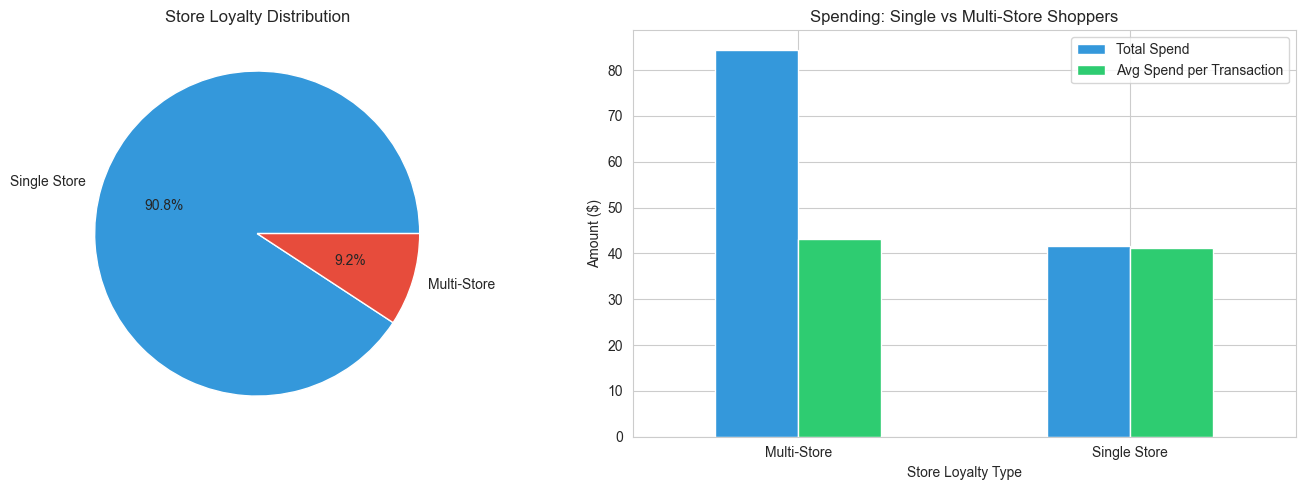

In [31]:
# Store loyalty analysis: Single vs Multi-store shoppers
customer_stats['store_loyalty'] = customer_stats['stores_visited'].apply(
    lambda x: 'Single Store' if x == 1 else 'Multi-Store'
)

print("=== Store Loyalty Analysis ===")
print(customer_stats['store_loyalty'].value_counts())

# Compare behavior
store_loyalty_comparison = customer_stats.groupby('store_loyalty').agg({
    'total_spend': 'mean',
    'avg_spend': 'mean',
    'transaction_count': 'mean',
    'avg_loyalty_points': 'mean'
}).round(2)
print("\n=== Single vs Multi-Store Shoppers ===")
print(store_loyalty_comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

customer_stats['store_loyalty'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                                                     colors=['#3498db', '#e74c3c'])
axes[0].set_title('Store Loyalty Distribution')
axes[0].set_ylabel('')

store_loyalty_comparison[['total_spend', 'avg_spend']].plot(kind='bar', ax=axes[1], color=['#3498db', '#2ecc71'])
axes[1].set_title('Spending: Single vs Multi-Store Shoppers')
axes[1].set_xlabel('Store Loyalty Type')
axes[1].set_ylabel('Amount ($)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Total Spend', 'Avg Spend per Transaction'])

plt.tight_layout()
plt.show()

=== Customer Preferred Aisles ===
preferred_aisle
Beverages            187
Canned Goods         183
Bakery               180
Frozen Foods         175
Personal Care        165
Health & Wellness    163
Household Items      160
Snacks & Candy       157
Dairy                152
Meat & Seafood       145
Produce              131
Name: count, dtype: int64


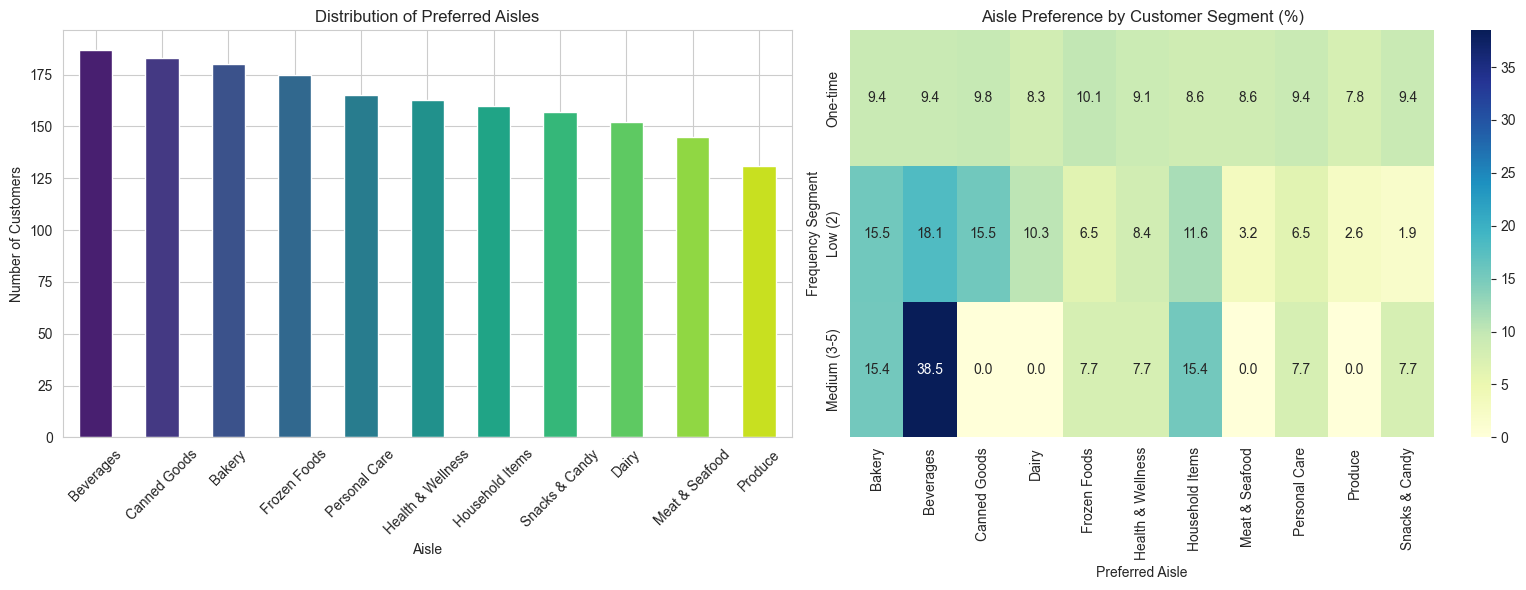

In [32]:
# Aisle preferences per customer - identify top aisles for each customer
def get_top_aisle(group):
    return group['aisle'].mode().iloc[0] if len(group['aisle'].mode()) > 0 else None

customer_top_aisle = df.groupby('customer_id').apply(get_top_aisle).reset_index()
customer_top_aisle.columns = ['customer_id', 'preferred_aisle']

print("=== Customer Preferred Aisles ===")
aisle_preference = customer_top_aisle['preferred_aisle'].value_counts()
print(aisle_preference)

# Heatmap: Customer segments vs Aisle preferences
# Merge with customer stats
customer_with_aisle = customer_stats.reset_index().merge(customer_top_aisle, on='customer_id')

segment_aisle = pd.crosstab(customer_with_aisle['frequency_segment'], 
                            customer_with_aisle['preferred_aisle'], 
                            normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

aisle_preference.plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', len(aisle_preference)))
axes[0].set_title('Distribution of Preferred Aisles')
axes[0].set_xlabel('Aisle')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(segment_aisle, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Aisle Preference by Customer Segment (%)')
axes[1].set_xlabel('Preferred Aisle')
axes[1].set_ylabel('Frequency Segment')

plt.tight_layout()
plt.show()

## 17. Summary & Recommendations

### Key Findings:

**1. Discount Impact:**
- Average discount rate across all transactions
- High-discount transactions show different basket values compared to no-discount
- Certain aisles and products receive more discounts

**2. Store Performance:**
- Significant variation in AOV, discount rates, and loyalty engagement across stores
- Top and bottom performers identified using composite scoring

**3. Loyalty Program:**
- Correlation between loyalty points and spending behavior
- Different tiers show distinct purchasing patterns

**4. Anomalies:**
- Negative final_amount transactions caused by discounts exceeding total amount
- These are promotional over-discounts, not returns

**5. Customer Segments:**
- Mix of one-time and repeat customers
- Store loyalty varies significantly
- Clear aisle preferences by customer segment

### Recommendations for Promotion Strategy:

1. **Discount Optimization**: Review >50% discount cases for policy compliance
2. **Store-Specific Promotions**: Tailor promotions based on store performance profiles
3. **Loyalty Tier Targeting**: Different promotion strategies for low vs high loyalty customers
4. **Aisle-Based Campaigns**: Focus promotions on high-traffic, lower-discount aisles to drive engagement
5. **Anomaly Prevention**: Implement validation rules to prevent discount > total amount scenarios